# Kalman Filter: acceleration as state

As an alternative, the third option considered in this notebook uses an **augmented state** so acceleration is **estimated**, not injected as a control input.

We measure:
- position (noisy)
- acceleration (noisy, IMU-like)

This is again a common pattern for fusing **position + IMU acceleration** in 1D.

The underlying dynamics reamins the same (refer to one of the previous notebooks for an overview of the equations).

## 2. Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


def simulate_linear_model(n_steps: int,
                          dt: float,
                          p0: float,
                          v0: float,
                          a0: float,
                          sigma_j: float,
                          sigma_y_pos: float,
                          sigma_y_acc: float,
                          seed: int = 0):
    """
    Generate simulated motion of a point in 1D according to linear model
    
    Args:
        n_steps (int): number of steps to simulate.
        dt (float): time step.
        p0 (float): initial position.
        v0 (float): initial velocity.
        a0 (float): initial acceleration.
        sigma_j (float): standard deviation/intensity of jerk.
        sigma_y_pos (float): standard deviation of position measurement noise. If set <0, auto set to 0 ==> equal to true values
        sigma_y_acc (float): standard deviation of acceleration measurement noise. If set <0, auto set to 0 ==> equal to true values
        seed (int, optional): random seed for reproducibility. Defaults to 0.

    Returns:
        tuple: (true_pos, true_vel, y_pos, y_acc) arrays of positions, velocities, pos and acc measurements.
    
    Sensors:
        position measurement: y_pos = x + N(0, sigma_y_pos^2)
        acceleration measurement: y_acc = a + N(0, sigma_y_acc^2)
    """
    p = float(p0)
    v = float(v0)
    a = float(a0)

    A = np.array([
        [1.0, dt, 0.5*dt**2],
        [0.0, 1.0, dt],
        [0.0, 0.0, 1.0]
    ])

    H = np.array([
        [1, 0, 0],
        [0, 0, 1]
    ])

    sigma_j = np.max([0, sigma_j]).astype(float)
    sigma_y_pos = np.max([0, sigma_y_pos]).astype(float)
    sigma_y_acc = np.max([0, sigma_y_acc]).astype(float)

    Q = sigma_j**2 * np.array([
        [dt**5/20, dt**4/8,  dt**3/6],
        [dt**4/8,  dt**3/3,  dt**2/2],
        [dt**3/6,  dt**2/2,  dt]
    ])

    R = np.diag([sigma_y_pos**2, sigma_y_acc**2])

    pos, vel, acc = [], [], []
    y_pos, y_acc = [], []
    x = np.array([p, v, a]).reshape(3, 1)

    for k in range(n_steps):
        # acceleration
        rng = np.random.default_rng(seed + k)

        # sample noise
        w = rng.multivariate_normal(np.zeros(3), Q).reshape(3,1)

        # interate/integrate
        x = A @ x + w

        # extract
        p = x[0,0]
        v = x[1,0]
        a = x[2,0]

        # append history
        pos.append(p)
        vel.append(v)
        acc.append(a)

        # noisy pos + acc measurements
        v = rng.multivariate_normal(np.zeros(2), R).reshape(2,1)
        y = H @ x + v
        y_pos.append(y[0, 0])
        y_acc.append(y[1, 0])

    return (np.array(pos), np.array(vel), np.array(acc),
            np.array(y_pos), np.array(y_acc))

## 3. Kalman filter (state = position, velocity, acceleration)

Now the filter model changes. We consider accelearation as a state rather than
as a drivin input. This resembles the real system dynamics and has the advantage
to automatically produce estimated values for accelerations as well.

The filter model becomes:
$$
\begin{bmatrix} x_{k+1} \\ v_{k+1} \\ a_{k+1} \end{bmatrix} = A \begin{bmatrix} x_k \\ v_k \\ a_k \end{bmatrix}  + \mathsf{w}_k, \quad \mathsf{w}_k\sim\mathcal{N}(0,Q)
$$

where

$$
A = \begin{bmatrix}
1 & dt & \tfrac{1}{2}dt^2 \\
0 & 1  & dt \\
0 & 0  & 1
\end{bmatrix}
$$

Process noise comes from **white jerk** (jerk intensity $\sigma_j^2$). The standard discrete $Q$ for this model is:
$$
Q = \sigma_j^2 \begin{bmatrix}
\tfrac{dt^5}{20} & \tfrac{dt^4}{8} & \tfrac{dt^3}{6} \\
\tfrac{dt^4}{8}  & \tfrac{dt^3}{3} & \tfrac{dt^2}{2} \\
\tfrac{dt^3}{6}  & \tfrac{dt^2}{2} & dt
\end{bmatrix}
$$

Measurements:
$$
y_k = \begin{bmatrix} y^{(pos)}_k \\ y^{(acc)}_k \end{bmatrix} = H\begin{bmatrix} x_k \\ v_k \\ a_k \end{bmatrix} + \mathsf{v}_k,\quad
$$

where $H = \begin{bmatrix}1 & 0 & 0\\ 0 & 0 & 1\end{bmatrix}$, $\mathsf{v}_k\sim\mathcal{N}(0,R)$ and $R=\begin{bmatrix} \sigma_{\mathsf{v}}^2 & \\ & \sigma_{\mathsf{a}}^2\end{bmatrix}$ 

So we directly observe **position** and **acceleration**.


In [2]:
def kalman_filter_acceleration_as_state(y_pos: np.ndarray,
                                        y_acc: np.ndarray,
                                        dt: float,
                                        x0: np.ndarray,
                                        P0: np.ndarray,
                                        sigma_j: float,
                                        sigma_y_pos: float,
                                        sigma_y_acc: float):
    """Kalman filter with augmented state x=[pos, vel, acc]^T.

    - Process noise modeled as white jerk with std sigma_j
    - Measurements: position and acceleration
    """
    A = np.array([
        [1.0, dt, 0.5*dt**2],
        [0.0, 1.0, dt],
        [0.0, 0.0, 1.0]
    ])

    H = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0]
    ])

    R = np.diag([sigma_y_pos**2, sigma_y_acc**2])
    Q = sigma_j**2 * np.array([
        [dt**5/20, dt**4/8,  dt**3/6],
        [dt**4/8,  dt**3/3,  dt**2/2],
        [dt**3/6,  dt**2/2,  dt]
    ])

    I = np.eye(3)
    x = x0.reshape(3, 1)
    P = P0.copy()

    xs = []
    Ps = []

    for yp, ya in zip(y_pos, y_acc):
        y = np.array([[yp], [ya]])

        # Predict
        x_pred = A @ x
        P_pred = A @ P @ A.T + Q

        # Update
        e = y - (H @ x_pred)
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x = x_pred + K @ e
        P = (I - K @ H) @ P_pred

        xs.append(x.flatten())
        Ps.append(P.copy())

    return np.array(xs), np.array(Ps)


## 4. Run simulation + filter

In [3]:
dt = 0.1
n_steps = 200
p0 = 0
v0 = 0
a0 = 0

# True motion (jerk drives acceleration changes)
sigma_j_true = 0.8

# Sensor noise
sigma_y_pos_true = 2.0
sigma_y_acc_true = 0.8

true_pos, true_vel, true_acc, y_pos, y_acc = simulate_linear_model(
    n_steps, dt, 
    p0, v0, a0,
    sigma_j_true, sigma_y_pos_true, sigma_y_acc_true,
    seed=42
)

# Filter assumptions (try changing these)
sigma_a_filter = 0.8
sigma_y_pos_filter = 2.0
sigma_y_acc_filter = 0.8

x0 = np.array([0.0, 0.0, 0.0])
P0 = np.diag([10.0**2, 10.0**2, 5.0**2])  # now bigger since extended state

xs, Ps = kalman_filter_acceleration_as_state(
    y_pos, y_acc, dt, x0, P0, sigma_a_filter, sigma_y_pos_filter, sigma_y_acc_filter
)

est_pos = xs[:, 0]
est_vel = xs[:, 1]
est_acc = xs[:, 2]
t = np.arange(n_steps) * dt
sigma_pos = np.sqrt(Ps[:, 0, 0])
sigma_vel = np.sqrt(Ps[:, 1, 1])
sigma_acc = np.sqrt(Ps[:, 2, 2])

mse_pos = np.mean((true_pos - est_pos)**2)
mse_vel = np.mean((true_vel - est_vel)**2)
mse_acc = np.mean((true_acc - est_acc)**2)

print(f"Position MSE: {mse_pos:.4f}")
print(f"Velocity MSE: {mse_vel:.4f}")
print(f"Acceleration MSE: {mse_acc:.4f}")


Position MSE: 0.5156
Velocity MSE: 0.5866
Acceleration MSE: 0.2540


## 5. Plots

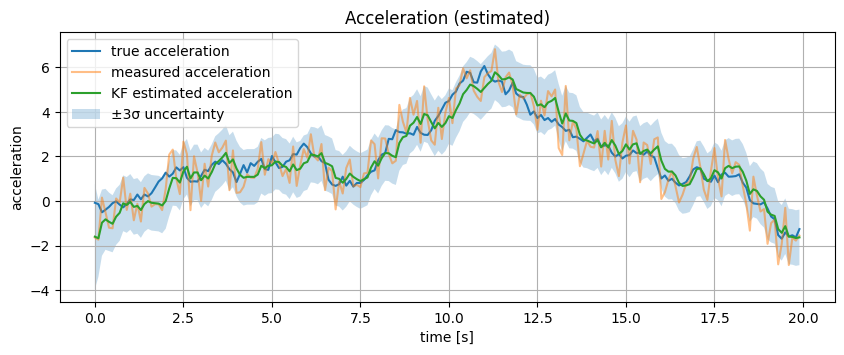

In [4]:
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_acc, label='true acceleration')
plt.plot(t, y_acc, alpha=0.5, label='measured acceleration')
plt.plot(t, est_acc, label='KF estimated acceleration')
plt.fill_between(t, est_acc - 3*sigma_acc, est_acc + 3*sigma_acc, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('acceleration')
plt.title('Acceleration (estimated)')
plt.grid(True)
plt.legend()
plt.show()

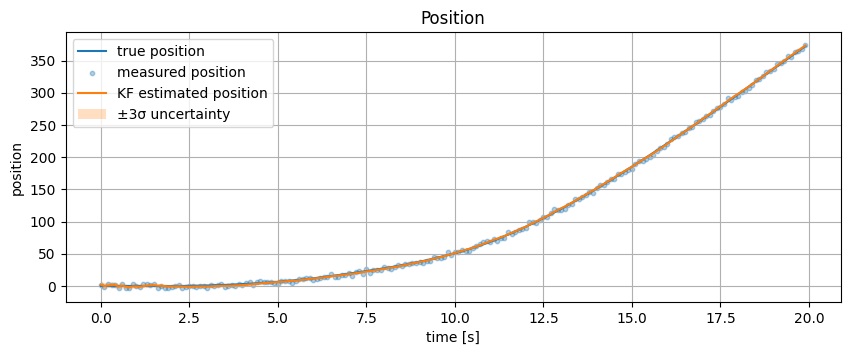

In [5]:
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_pos, label='true position')
plt.scatter(t, y_pos, s=10, alpha=0.35, label='measured position')
plt.plot(t, est_pos, label='KF estimated position')
plt.fill_between(t, est_pos - 3*sigma_pos, est_pos + 3*sigma_pos, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('position')
plt.title('Position')
plt.grid(True)
plt.legend()
plt.show()

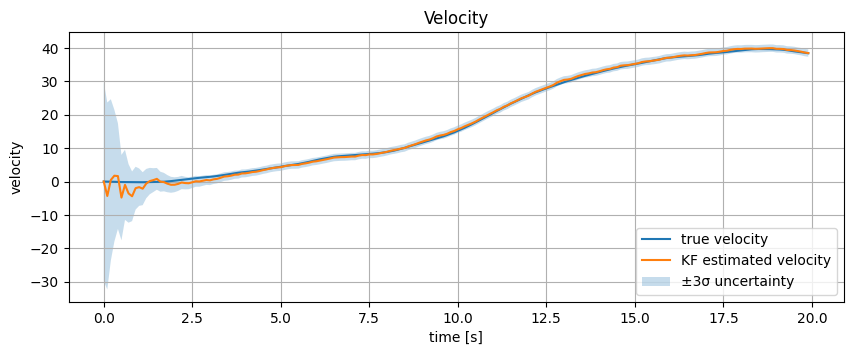

In [6]:
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_vel, label='true velocity')
plt.plot(t, est_vel, label='KF estimated velocity')
plt.fill_between(t, est_vel - 3*sigma_vel, est_vel + 3*sigma_vel, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('velocity')
plt.title('Velocity')
plt.grid(True)
plt.legend()
plt.show()